# Technology in the UN General Debate, 1946-2025

### SDG 9 - Industry, Innovation and Infrastructure · Theme: *"Restoring trust, managing transformation"*

The 81st General Assembly asks the world to **restore trust** while **managing
transformation**. The transformation everyone means is the digital one, and the
trust problem is increasingly *about* it: the same technology that member states
spent sixty years asking to be given is now the thing they ask to be protected
from. **SDG 9** - and in particular target **9.c**, "significantly increase access
to ICT and strive to provide universal and affordable access to the Internet" -
is where those two halves of the theme meet.

**Exploratory question**
> How has the way states talk about technology in the General Debate changed
> between 1946 and 2025 - in how much they say, *which* technology they name, and
> whether they frame it as a promise or a peril - and does a country's position in
> the global digital divide predict which of those framings it uses?

**Predictive question**
> Can we predict how connected a country actually is (internet users, % of
> population) from the text of its General Debate speech alone, and does its
> technology discourse carry information that GDP per capita and the year do not
> already contain? Then the forward-looking half: does what a country says today
> predict how fast it gets online over the *next five years*, and how much it will
> be **investing in research** five years from now?

**Datasets**

| # | Dataset | Grain | Used for |
|---|---|---|---|
| 1 | **UN General Debate Corpus v14** (Jankin, Baturo & Dasandi 2025) | speech = country-year, 11,141 rows, 1946-2025 | the text |
| 2 | **World Bank WDI** - connectivity (`IT.NET.USER.ZS`, `IT.CEL.SETS.P2`, `IT.NET.BBND.P2`) and the control (`NY.GDP.PCAP.PP.KD`, `SP.POP.TOTL`) | country-year | the section 8 target and the economic control |
| 2b | **World Bank WDI** - technology investment (`GB.XPD.RSDV.GD.ZS` R&D % of GDP = SDG 9.5.1, plus `SP.POP.SCIE.RD.P6`, `IP.PAT.RESD`, `IP.JRN.ARTC.SC`, `TX.VAL.TECH.MF.ZS`) | country-year | the section 10 target |
| 3 | **UN E-Government Development Index** (via World Bank Data360) | country-year, biennial 2003-2024 | second connectivity target / robustness |
| 4 | **World Happiness Report** `DataForTable2.1` | country-year, 2005-2024 | the trust side of the theme (perceived corruption, life evaluation) |
| 5 | **UNSD M49** | country | region, and the LDC / LLDC / SIDS development groups |

**Why not education.** An earlier version of this question asked whether countries
that speak positively about technology *in education* end up with more ICT in
classrooms. Only 4.2% of speeches contain a single sentence mentioning both
topics, and the World Bank's classroom-ICT indicator is almost empty. There is no
dataset there. This notebook keeps the technology half, where there are 11,141
speeches and a well-measured outcome.

---

## 0. Setup

Paths and lexicons come from the installed package, so every cell works
regardless of which directory the kernel started in.

In [2]:
import json
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from un_general_debate_analysis.preprocessing import OUT_DIR, META_COLUMNS
from un_general_debate_analysis.lexicons import (
    CO_OCCURRENCE_PAIRS,
    FRAME_LEXICONS,
    LEXICONS,
    TECH_FACETS,
    TERM_NOTES,
)
from un_general_debate_analysis.external import load_all
from un_general_debate_analysis.subcorpus import lexicon_sentences

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# One palette for the whole notebook. Categorical hues are assigned in a fixed
# order and never cycled, so a colour always means the same thing.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
          "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = SERIES
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#dddcd7"
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlecolor": INK,
    "axes.titlelocation": "left", "axes.titlepad": 10, "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "grid.alpha": 0.9,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2.0, "lines.markersize": 5,
    "font.size": 10,
})


def finish(ax, title=None, subtitle=None, xlabel=None, ylabel=None, legend=True):
    """Titles, labels and a recessive grid, applied the same way everywhere."""
    if title:
        ax.set_title(title)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=9,
                color=INK_SOFT, va="bottom")
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    ax.set_axisbelow(True)
    if legend and ax.get_legend_handles_labels()[0]:
        ax.legend(loc="best")
    return ax


print(f"lexicons: {list(LEXICONS)}")

lexicons: ['theme_trust', 'theme_transformation', 'theme_multilateralism', 'tech_access', 'tech_frontier', 'tech_security', 'tech_governance', 'tech_economy', 'frame_promise', 'frame_peril', 'education', 'technology']


In [3]:
features = pd.read_csv(OUT_DIR / "speeches_features.csv")
terms = pd.read_csv(OUT_DIR / "lexicon_terms_by_year.csv")
external = load_all(verbose=True)

print(f"features : {features.shape[0]:,} speeches x {features.shape[1]} columns, "
      f"{features['year'].min()}-{features['year'].max()}")
print(f"terms    : {terms.shape[0]:,} (year x lexicon x term) rows")

if len(features) < 10_000:
    raise SystemExit("Only a sample in data/processed - re-run the pipeline without --limit.")

World Happiness: 4 country names unmatched -> ['Hong Kong S.A.R. of China', 'Kosovo', 'Somaliland region', 'Taiwan Province of China']
external panel: 17,139 country-years, 260 countries, 1960-2025
features : 11,141 speeches x 107 columns, 1946-2025
terms    : 13,470 (year x lexicon x term) rows


## 1. What changed in the text pipeline, and why

Three things were added to `lexicons.py` / `preprocessing.py` for this question.
All three are motivated by something that was wrong or missing before.

**(a) `technology` was hiding half of itself.** Multi-word terms are merged into a
single token by the phrase tokeniser, and the longest phrase wins. That means a
phrase *conceals the single words inside it*: because `theme_transformation`
registered `"digital divide"` as a phrase, every "digital divide" sentence became
the token `digital_divide` and stopped matching the bare `"digital"` entry in
`technology`. `"internet"` and `"cyber"` were in `theme_transformation` but never
in `technology` at all. The umbrella lexicon is now built as the **union of its
facets**, so no facet term can be invisible to it.

**(b) Three terms were doing real damage.** `network`, `cloud` and the bare
acronym `ai` were among the top six "technology" terms in the corpus. Reading the
matches: *"the network of solidarity"*, *"the clouds of war"*, and - for `ai` -
222 pre-2010 hits, which is impossible, because tokens are lowercased and OCR noise
and quoted French are indistinguishable from the acronym. They are dropped; the
unambiguous phrases (`neural network`, `cloud computing`, `artificial
intelligence`) are kept.

**(c) Two new measurement axes.** *Which* technology (five facets) and *how* it is
framed (promise / peril), the latter counted only inside technology sentences via
the new `CO_OCCURRENCE_PAIRS` machinery.

In [3]:
print("TECHNOLOGY FACETS  (what kind of technology is being talked about)\n")
for facet, words in TECH_FACETS.items():
    top = (terms[terms["lexicon"] == facet]
           .groupby("term")["count"].sum().sort_values(ascending=False).head(6))
    print(f"  {facet:<17} {len(words):>3} terms | top: "
          + ", ".join(f"{t} ({c:,})" for t, c in top.items()))

print("\nFRAMING DICTIONARIES  (only meaningful inside technology sentences)\n")
for frame, words in FRAME_LEXICONS.items():
    print(f"  {frame:<17} {len(words):>3} terms | e.g. " + ", ".join(words[:8]))

print("\nCO-OCCURRENCE PAIRS  (same-sentence overlap -> 3 columns each)\n")
for a, b in CO_OCCURRENCE_PAIRS:
    print(f"  {a} x {b}")

print("\nTERMS DELIBERATELY EXCLUDED\n")
for term, why in TERM_NOTES.items():
    print(f"  {term:<14} {why}")

TECHNOLOGY FACETS  (what kind of technology is being talked about)

  tech_access        37 terms | top: internet (313), connectivity (252), telecommunication (233), information and communication technology (215), information technology (196), digital divide (143)
  tech_frontier      34 terms | top: new technology (343), artificial intelligence (293), advance technology (121), drone (98), emerging technology (45), space technology (41)
  tech_security      35 terms | top: disinformation (225), cyberspace (117), hate speech (105), misinformation (92), cybersecurity (87), cybercrime (85)
  tech_governance    20 terms | top: science and technology (1,100), transfer of technology (431), technology transfer (278), technical cooperation (132), global digital compact (53), digital cooperation (33)
  tech_economy       32 terms | top: technology (3,769), technological (1,746), innovative (1,135), innovation (868), digital (539), modernization (500)

FRAMING DICTIONARIES  (only meaningful insi

## 2. Speech-level metrics

Raw counts are not comparable across speeches: length varies by a factor of sixty
in this corpus, and the number of countries speaking each year grows from ~50 to
~190. Everything below is a **rate**.

| Metric | Definition | Reads as |
|---|---|---|
| `tech_salience` | technology sentences / all sentences | how much of the speech is about technology |
| `tech_intensity` | technology terms per 1,000 words | the same, at word level |
| `<facet>_share` | facet sentences / technology sentences | *given* that it talks technology, which kind |
| `stance` | (promise - peril technology sentences) / technology sentences | +1 pure promise, -1 pure peril |
| `tech_tone` | (positive - negative technology sentences) / technology sentences | the same thing measured by VADER |
| `tech_tone_rel` | `tech_tone` - the speech's own tone | is technology spoken of *better than this speaker's baseline*? |
| `trust_overlap` | technology x theme\_trust sentences / technology sentences | technology discussed in the language of trust |

`tech_tone_rel` matters because diplomatic register differs enormously by country
and era. A country whose whole speech is grim will have a grim technology tone;
subtracting its own baseline asks the sharper question.

In [8]:
FACETS = ["tech_access", "tech_frontier", "tech_security", "tech_governance", "tech_economy"]
FACET_LABELS = {
    "tech_access": "Access & connectivity",
    "tech_frontier": "Frontier tech",
    "tech_security": "Security & harms",
    "tech_governance": "Transfer & governance",
    "tech_economy": "Innovation & economy",
}


def speech_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Length-normalised technology metrics, one row per speech."""
    tech = df["technology_sentences"].replace(0, np.nan)   # NaN when there is nothing to divide
    out = df[["country_code", "country", "year", "session", "region_name",
              "sub_region_name", "speaker_role"]].copy()
    out["n_sentences"] = df["n_sentences"]
    out["mentions_tech"] = df["technology"]
    out["tech_salience"] = df["technology_sentences"] / df["n_sentences"]
    out["tech_intensity"] = 1_000 * df["technology_count"] / df["n_words"]
    for facet in FACETS:
        out[f"{facet}_share"] = df[f"{facet}_sentences"] / tech
    out["promise_share"] = df["technology_frame_promise_sentences"] / tech
    out["peril_share"] = df["technology_frame_peril_sentences"] / tech
    out["stance"] = out["promise_share"] - out["peril_share"]
    out["tech_tone"] = (df["technology_positive_sentences"]
                        - df["technology_negative_sentences"]) / tech
    out["speech_tone"] = df["share_positive_sentences"] - df["share_negative_sentences"]
    out["tech_tone_rel"] = out["tech_tone"] - out["speech_tone"]
    out["tech_vader"] = df["technology_sentiment"].where(df["technology"] == 1)
    out["trust_overlap"] = df["technology_theme_trust_sentences"] / tech
    out["multilateral_overlap"] = df["technology_theme_multilateralism_sentences"] / tech
    out["trust_salience"] = df["theme_trust_sentences"] / df["n_sentences"]
    out["lexical_density"] = df["lexical_density"]
    out["mean_sentence_length"] = df["mean_sentence_length"]
    return out


speech = speech_metrics(features)
print(f"{len(speech):,} speeches, {speech['mentions_tech'].mean():.1%} mention technology at all")
speech[["tech_salience", "tech_intensity", "stance", "tech_tone",
        "tech_tone_rel", "trust_overlap"]].describe().T

11,141 speeches, 54.7% mention technology at all


,count,mean,std,min,25%,50%,75%,max
tech_salience,"11,141.000",0.013,0.021,0.000,0.000,0.007,0.018,0.358
tech_intensity,"11,141.000",0.625,1.251,0.000,0.000,0.253,0.716,23.077
stance,"6,099.000",0.162,0.456,-1.000,0.000,0.000,0.500,1.000
tech_tone,"6,099.000",0.448,0.693,-1.000,0.000,0.833,1.000,1.000
tech_tone_rel,"6,099.000",0.091,0.676,-1.745,-0.300,0.345,0.604,1.274
trust_overlap,"6,099.000",0.033,0.146,0.000,0.000,0.000,0.000,1.000


## 3. Do the new metrics measure what they claim?

A dictionary method that nobody reads the output of is a number generator. The
sentences themselves are pulled back out of the corpus and audited.

In [17]:
texts = pd.read_csv(OUT_DIR / "speeches_text.csv.gz", usecols=["country_code", "year", "text_clean"])

# ~35 s: re-segments and re-tokenises every speech from 1990 on.
tech_sentences = lexicon_sentences(texts[texts["year"] >= 1990], "technology")
tech_sentences = tech_sentences.merge(
    features[["country_code", "year", "region_name"]], on=["country_code", "year"], how="left")

print(f"{len(tech_sentences):,} technology sentences, "
      f"{tech_sentences['country_code'].nunique()} countries, 1990-2025")
print(f"  promise-framed : {tech_sentences['frame_promise'].mean():.1%}")
print(f"  peril-framed   : {tech_sentences['frame_peril'].mean():.1%}")
print(f"  security facet : {tech_sentences['tech_security'].mean():.1%}")

9,759 technology sentences, 198 countries, 1990-2025
  promise-framed : 24.7%
  peril-framed   : 11.4%
  security facet : 7.8%


In [18]:
rng = np.random.default_rng(11)


def show(frame, label, n=6, width=165):
    sample = frame.sample(min(n, len(frame)), random_state=11)
    print(f"--- {label}  (n = {len(frame):,}) ---")
    for _, row in sample.iterrows():
        print(f"  [{row.country_code} {row.year} vader {row.compound:+.2f}] {row.sentence[:width]}")
    print()


show(tech_sentences[tech_sentences["frame_peril"] == 1], "PERIL-framed technology sentences")
show(tech_sentences[tech_sentences["frame_promise"] == 1], "PROMISE-framed technology sentences")
show(tech_sentences[tech_sentences["tech_security"] == 1], "SECURITY-facet technology sentences")

--- PERIL-framed technology sentences  (n = 1,113) ---
  [HRV 2013 vader +0.97] To achieve a sustainable future, we need a concurrent base of strong institutions, solidarity, justice and social development, with an approach that is more targeted
  [KEN 2025 vader -0.51] Inequality deepens, pandemics loom, and technological disruptions outpaces governance.
  [VAT 2022 vader -0.97] Pope Francis points out that "the potential of digital technology is enormous, yet the possible negative impact of its abuse in the area of human trafficking, the pl
  [NPL 2016 vader +0.40] Special attention must be given to the climate-vulnerable countries, particularly mountainous countries, as regards providing resources and transferring technology f
  [VAT 2008 vader -0.34] The same principles that lead us to oppose unchecked technology and policies that destroy the environment should also guide us in our prudent use of technologies and
  [LVA 2021 vader -0.38] In Latvia, like elsewhere, youth are deeply 

### Audit result

Forty sentences (20 promise, 20 peril) were read by hand. The promise dictionary
is accurate - **~85%** of its hits are genuinely opportunity-framed technology
sentences. The peril dictionary is noisier, **~65-70%**: General Debate speeches
habitually list threats, and technology often appears *in the list* rather than
*as* the threat ("climate change, pandemics, terrorism and disinformation").

Two consequences, both applied below:

1. The **`tech_security` facet is the high-precision peril measure** - it only
   fires on words that are themselves technological harms (*disinformation,
   cybercrime, deepfake, autonomous weapon*). It is reported next to the framing
   index everywhere, and the two are expected to agree on direction.
2. The framing index is trustworthy as a **trend**, not as a level: its error rate
   is roughly constant over time, so a change in the index is a change in the
   world, while its absolute value is biased towards peril.

In [26]:
# How much do the domain-specific framing dictionaries add over VADER alone?
audit = tech_sentences.assign(
    frame=np.select([tech_sentences["frame_peril"].eq(1) & tech_sentences["frame_promise"].eq(0),
                     tech_sentences["frame_promise"].eq(1) & tech_sentences["frame_peril"].eq(0)],
                    ["peril only", "promise only"], default="both / neither"))

print(pd.crosstab(audit["frame"], audit["sentiment"], normalize="index")
        .rename_axis(index="framing dictionary", columns="VADER label")
        .mul(100).round(1).to_string(), "\n")

security = tech_sentences[tech_sentences["tech_security"] == 1]
print(f"Sentences naming a technological harm (tech_security): {len(security):,}")
print(f"  VADER calls {security['sentiment'].eq('positive').mean():.0%} of them POSITIVE "
      f"and {security['sentiment'].eq('neutral').mean():.0%} neutral.")
print("  -> VADER does not know 'cyberattack', 'disinformation' or 'deepfake'.")
print("     That gap is exactly what the domain dictionaries are for.")

VADER label         negative  neutral  positive
framing dictionary                             
both / neither        17.300   16.100    66.700
peril only            57.300    6.800    35.900
promise only           9.600    5.200    85.200 

Sentences naming a technological harm (tech_security): 762
  VADER calls 35% of them POSITIVE and 9% neutral.
  -> VADER does not know 'cyberattack', 'disinformation' or 'deepfake'.
     That gap is exactly what the domain dictionaries are for.


---
## 4. Eighty years of technology talk

Two facts first: how *often* technology comes up, and how *much* of a speech it
takes up when it does. They are plotted separately rather than on twin axes -
different units, so a shared axis would be a lie.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


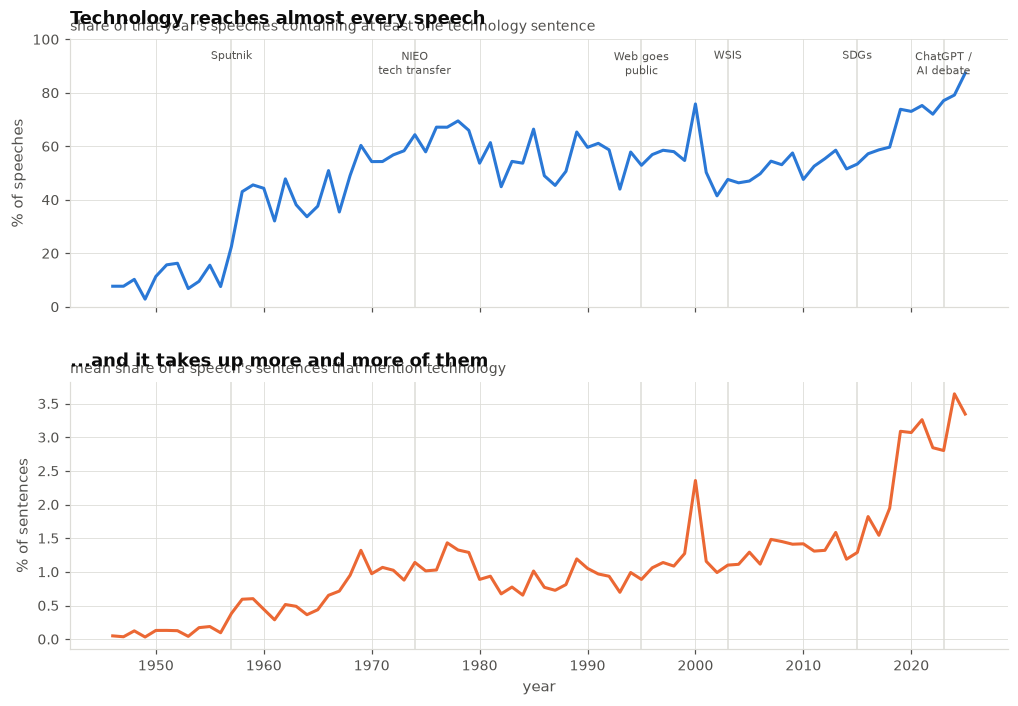

      speeches  share_mentioning  salience  intensity
year                                                 
1950        44            11.400     0.130      0.050
1970        70            54.300     0.970      0.330
1990       156            59.600     1.050      0.430
2000       178            75.800     2.360      1.090
2010       189            47.600     1.420      0.670
2020       193            73.100     3.070      1.780
2025       190            87.400     3.340      2.190


In [27]:
yearly = speech.groupby("year").agg(
    speeches=("country_code", "size"),
    share_mentioning=("mentions_tech", "mean"),
    salience=("tech_salience", "mean"),
    intensity=("tech_intensity", "mean"),
)

ERAS = [(1957, "Sputnik"), (1974, "NIEO\ntech transfer"), (1995, "Web goes\npublic"),
        (2003, "WSIS"), (2015, "SDGs"), (2023, "ChatGPT /\nAI debate")]

fig, axes = plt.subplots(2, 1, figsize=(11, 7.2), sharex=True,
                         gridspec_kw={"hspace": 0.28})

axes[0].plot(yearly.index, 100 * yearly["share_mentioning"], color=BLUE)
finish(axes[0], "Technology reaches almost every speech",
       "share of that year's speeches containing at least one technology sentence",
       ylabel="% of speeches", legend=False)
axes[0].set_ylim(0, 100)

axes[1].plot(yearly.index, 100 * yearly["salience"], color=ORANGE)
finish(axes[1], "...and it takes up more and more of them",
       "mean share of a speech's sentences that mention technology",
       xlabel="year", ylabel="% of sentences", legend=False)

for ax in axes:
    for year, label in ERAS:
        ax.axvline(year, color=GRID, lw=1, zorder=0)
for year, label in ERAS:
    axes[0].annotate(label, (year, 96), fontsize=7.5, color=INK_SOFT,
                     ha="center", va="top")
plt.show()

print(yearly.loc[[1950, 1970, 1990, 2000, 2010, 2020, 2025]]
      .assign(share_mentioning=lambda f: (100 * f.share_mentioning).round(1),
              salience=lambda f: (100 * f.salience).round(2),
              intensity=lambda f: f.intensity.round(2)).to_string())

In 1950, 11% of speeches mentioned technology and it took up 0.13% of their
sentences. In 2025, **87% of speeches** mention it and it takes up **3.3% of all
sentences** - twenty-five times the attention.

The series is not a smooth ramp. It climbs through the 1970s, plateaus for two
decades at around 1% of sentences, spikes once in 2000 (the Millennium Summit
year, when nearly every speech discussed the "information revolution"), and then
from 2019 rises to a level it has not left since.

Those episodes are not the same conversation, as the facets show.

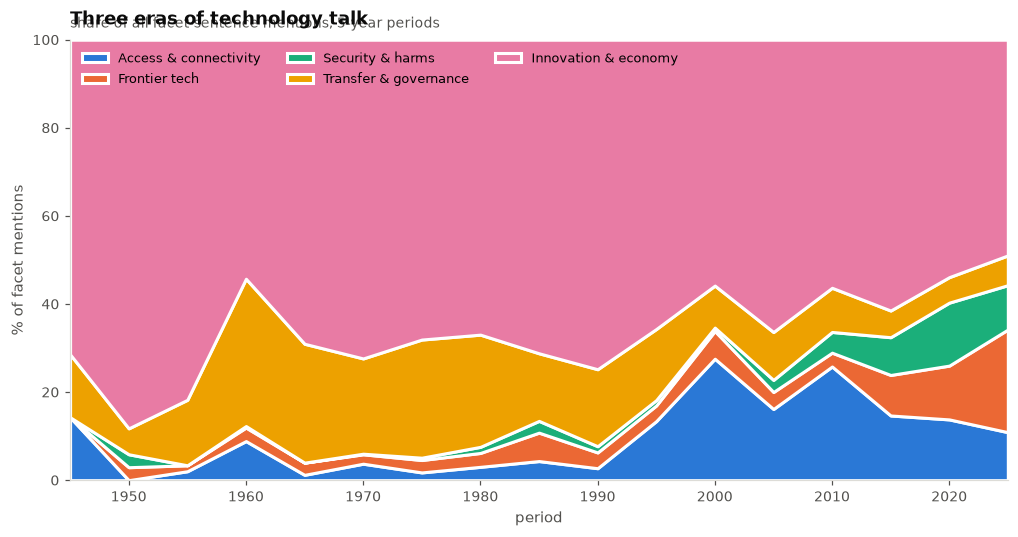

        Access & connectivity  Frontier tech  Security & harms  Transfer & governance  Innovation & economy
period                                                                                                     
1945                   14.300          0.000             0.000                 14.300                71.400
1950                    0.000          2.900             2.900                  5.900                88.200
1955                    2.000          1.400             0.000                 14.900                81.800
1960                    8.900          3.100             0.300                 33.400                54.300
1965                    1.200          2.800             0.000                 27.000                69.000
1970                    3.700          2.100             0.100                 21.600                72.400
1975                    1.800          2.800             0.500                 26.800                68.100
1980                    3.00

In [30]:
facet_year = (features.assign(period=(features["year"] // 5) * 5)
              .groupby("period")[[f"{f}_sentences" for f in FACETS]].sum())
facet_year.columns = [FACET_LABELS[c.replace("_sentences", "")] for c in facet_year.columns]
facet_mix = facet_year.div(facet_year.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.stackplot(facet_mix.index, *[100 * facet_mix[c] for c in facet_mix.columns],
             labels=facet_mix.columns, colors=SERIES[:5], edgecolor="white", linewidth=2)
finish(ax, "Three eras of technology talk",
       "share of all facet-sentence mentions, 5-year periods",
       xlabel="period", ylabel="% of facet mentions")
ax.set_ylim(0, 100)
ax.set_xlim(facet_mix.index.min(), facet_mix.index.max())
ax.legend(loc="upper left", ncols=3, fontsize=8.5)
plt.show()

print((100 * facet_mix).round(1).to_string())

**Era 1 - *Transfer* (1960-1985).** Up to a third of technology mentions are
`Transfer & governance`: *science and technology*, *transfer of technology*,
*technical cooperation*. This is the New International Economic Order argument -
technology as something the industrialised world holds and the developing world
is owed.

**Era 2 - *Access* (1995-2010).** `Access & connectivity` jumps from 3% to 28%.
*Internet*, *connectivity*, *digital divide*, *ICT*. The demand changes from
"transfer the technology" to "connect us". This peak lines up with the World
Summit on the Information Society (2003/2005).

**Era 3 - *Risk* (2015-2025).** `Security & harms` goes from ~1% of mentions
before 2010 to **14%** in 2020-24, and `Frontier tech` reaches **23%** in 2025 -
almost entirely artificial intelligence. Meanwhile `Transfer & governance` has
collapsed to 6%. The conversation is no longer about getting technology; it is
about surviving it.

In [35]:
era_terms = (terms[terms["lexicon"].isin(FACETS)]
             .assign(era=pd.cut(terms["year"], [1945, 1985, 2010, 2026],
                                labels=["1946-1985", "1986-2010", "2011-2025"])))
top_by_era = (era_terms.groupby(["era", "term"], observed=True)["count"].sum()
              .groupby("era", observed=True, group_keys=False)
              .nlargest(12).reset_index())
print(top_by_era.pivot_table(index=top_by_era.groupby("era", observed=True).cumcount() + 1,
                             columns="era", values="term", aggfunc="first").to_string())

era                  1946-1985                                 1986-2010                2011-2025
1                   technology                                technology               technology
2                technological                             technological               innovation
3       science and technology                                innovative               innovative
4       transfer of technology                    science and technology                  digital
5       technological progress                             modernization            technological
6          scientific research                                innovation  artificial intelligence
7                modernization                    transfer of technology             connectivity
8                   innovation                    information technology                 internet
9        technological advance                            new technology           disinformation
10   technological d

---
## 5. From promise to peril

The framing index is a diverging quantity - positive means the promise vocabulary
outweighs the peril vocabulary inside technology sentences - so it gets a
diverging colour scheme and a zero line.

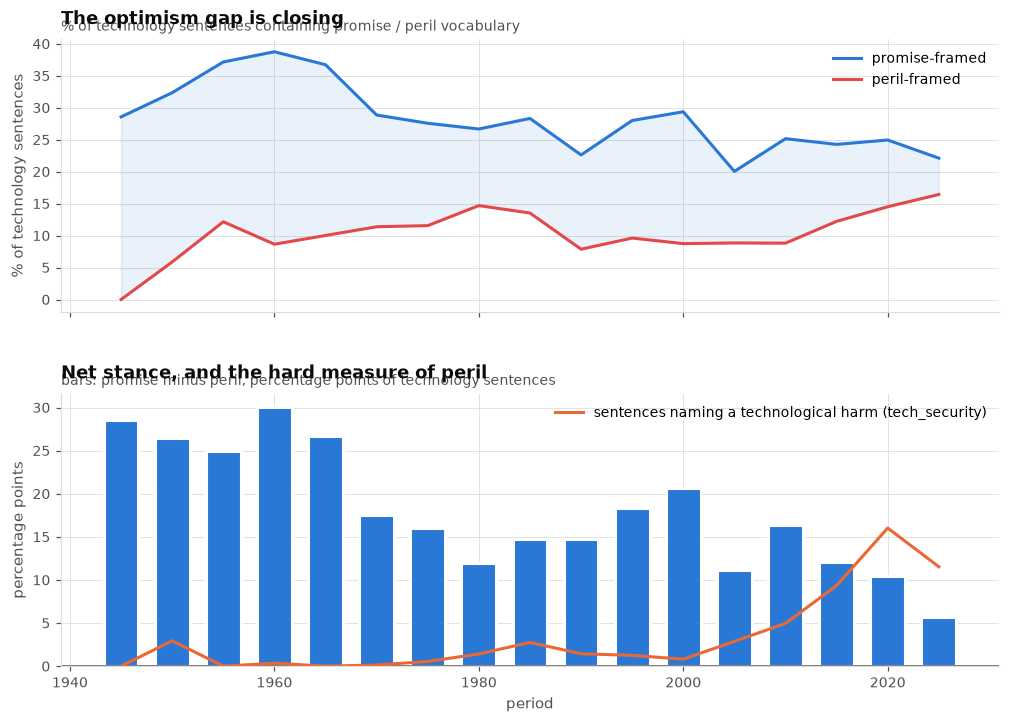

        tech  promise_rate  peril_rate  stance  security_rate
period                                                       
1945      14        28.600       0.000  28.600          0.000
1950      34        32.400       5.900  26.500          2.900
1955     148        37.200      12.200  25.000          0.000
1960     289        38.800       8.700  30.100          0.300
1965     569        36.700      10.000  26.700          0.000
1970     738        28.900      11.400  17.500          0.100
1975    1099        27.600      11.600  16.000          0.500
1980     776        26.700      14.700  12.000          1.400
1985     872        28.300      13.500  14.800          2.800
1990     902        22.600       7.900  14.700          1.400
1995     957        28.000       9.600  18.400          1.300
2000     984        29.400       8.700  20.600          0.800
2005     938        20.000       8.800  11.200          2.900
2010    1089        25.200       8.800  16.300          5.000
2015    

In [36]:
frame_year = features.assign(period=(features["year"] // 5) * 5).groupby("period").agg(
    tech=("technology_sentences", "sum"),
    promise=("technology_frame_promise_sentences", "sum"),
    peril=("technology_frame_peril_sentences", "sum"),
    security=("tech_security_sentences", "sum"),
)
frame_year["promise_rate"] = frame_year["promise"] / frame_year["tech"]
frame_year["peril_rate"] = frame_year["peril"] / frame_year["tech"]
frame_year["stance"] = frame_year["promise_rate"] - frame_year["peril_rate"]
frame_year["security_rate"] = frame_year["security"] / frame_year["tech"]

fig, axes = plt.subplots(2, 1, figsize=(11, 7.4), sharex=True,
                         gridspec_kw={"hspace": 0.30})

axes[0].plot(frame_year.index, 100 * frame_year["promise_rate"], color=BLUE, label="promise-framed")
axes[0].plot(frame_year.index, 100 * frame_year["peril_rate"], color=RED, label="peril-framed")
axes[0].fill_between(frame_year.index, 100 * frame_year["peril_rate"],
                     100 * frame_year["promise_rate"], color=BLUE, alpha=0.10)
finish(axes[0], "The optimism gap is closing",
       "% of technology sentences containing promise / peril vocabulary",
       ylabel="% of technology sentences")

axes[1].axhline(0, color=INK_SOFT, lw=1)
colors = [BLUE if v >= 0 else RED for v in frame_year["stance"]]
axes[1].bar(frame_year.index, 100 * frame_year["stance"], width=3.4,
            color=colors, edgecolor="white", linewidth=2)
axes[1].plot(frame_year.index, 100 * frame_year["security_rate"], color=ORANGE,
             label="sentences naming a technological harm (tech_security)")
finish(axes[1], "Net stance, and the hard measure of peril",
       "bars: promise minus peril, percentage points of technology sentences",
       xlabel="period", ylabel="percentage points")
plt.show()

print((frame_year[["tech", "promise_rate", "peril_rate", "stance", "security_rate"]]
       .assign(**{c: lambda f, c=c: (100 * f[c]).round(1)
                  for c in ["promise_rate", "peril_rate", "stance", "security_rate"]})
       .to_string()))

The net stance runs from **+29 points in 1946-50 and +30 in the early 1960s down
to +5.7 in 2025** - the lowest value in the corpus. The peril rate is at its
all-time high (16.4% of technology sentences), and the independent,
high-precision `tech_security` measure rises in step, from under 1% before 2005
to **16% in 2020-24**. The two measures were built differently and agree, which
is the point of having both.

There is also a visible dip in 1980-85 (stance +12) - the debt-crisis end of the
NIEO era, where technology appears in grievance framing ("technology gap",
"widening gap") rather than opportunity framing.

Notice what VADER says about the same sentences.

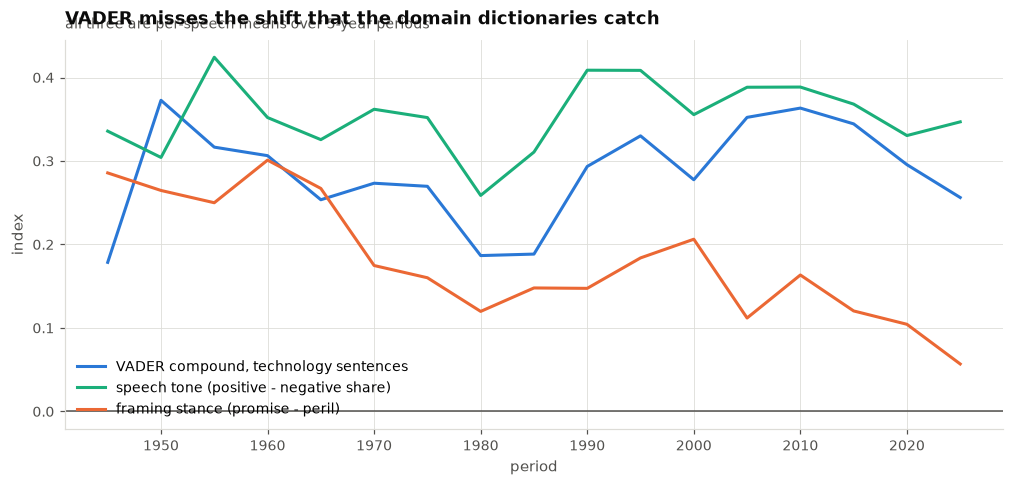

            stance  tech_tone  tech_vader
stance       1.000      0.258       0.307
tech_tone    0.258      1.000       0.900
tech_vader   0.307      0.900       1.000

stance vs VADER tone: r = 0.258 - related, but far from the same measurement.


In [37]:
vader_year = (speech[speech["mentions_tech"] == 1]
              .assign(period=lambda f: (f["year"] // 5) * 5)
              .groupby("period")[["tech_vader", "tech_tone", "tech_tone_rel", "speech_tone"]].mean())

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.axhline(0, color=INK_SOFT, lw=1)
ax.plot(vader_year.index, vader_year["tech_vader"], color=BLUE,
        label="VADER compound, technology sentences")
ax.plot(vader_year.index, vader_year["speech_tone"], color=AQUA,
        label="speech tone (positive - negative share)")
ax.plot(frame_year.index, frame_year["stance"], color=ORANGE,
        label="framing stance (promise - peril)")
finish(ax, "VADER misses the shift that the domain dictionaries catch",
       "all three are per-speech means over 5-year periods",
       xlabel="period", ylabel="index")
plt.show()

corr = speech[speech["mentions_tech"] == 1][["stance", "tech_tone", "tech_vader"]].corr()
print(corr.round(3).to_string())
print(f"\nstance vs VADER tone: r = {corr.loc['stance', 'tech_tone']:.3f} - "
      "related, but far from the same measurement.")

VADER's technology sentiment is essentially **flat**: it ends the period near
where it started, and its 2005-2015 values are among the *highest* in the whole
series - exactly the decades when the peril vocabulary was taking off. It cannot
see the change because its lexicon contains none of the words that carry it:
`cyberattack`, `disinformation`, `deepfake`, `surveillance` and `autonomous
weapon` are simply not scored. The correlation between the framing stance and
the VADER tone is **r = 0.26**, so these are genuinely two different
measurements, and only one of them is about technology.

**This is the answer to the original question in its corrected form.** "Do
countries speak positively about technology?" is not answerable with a
general-purpose sentiment model; the sentiment has to be measured in the
vocabulary of the domain.

---
## 6. The discourse divide

Now the external data. Each speech is matched to its country's internet
penetration, GDP per capita, EGDI and happiness-report measures **in the same
year**, and countries are split into terciles of connectivity *within each year*,
so "least connected" means least connected relative to its contemporaries rather
than simply earlier.

In [39]:
panel = speech.merge(external, on=["country_code", "year"], how="left")
panel["log_gdp"] = np.log(panel["gdp_per_capita_ppp"])

modern = panel[(panel["year"] >= 1995) & panel["internet_users_pct"].notna()].copy()
modern["connectivity_tercile"] = (modern.groupby("year")["internet_users_pct"]
                                  .transform(lambda s: pd.qcut(s.rank(method="first"), 3,
                                                               labels=["least connected",
                                                                       "middle",
                                                                       "most connected"])))
coverage = panel[panel["year"] >= 1990].assign(period=lambda f: (f["year"] // 5) * 5).groupby("period").agg(
    speeches=("country_code", "size"),
    internet=("internet_users_pct", "count"),
    gdp=("gdp_per_capita_ppp", "count"),
    egdi=("egdi", "count"),
    happiness=("life_ladder", "count"))
print("external-data coverage of the speeches\n")
print(coverage.to_string())
print(f"\nmodelling window: {len(modern):,} speeches, "
      f"{modern['country_code'].nunique()} countries, "
      f"{modern['year'].min()}-{modern['year'].max()}")

external-data coverage of the speeches

        speeches  internet  gdp  egdi  happiness
period                                          
1990         838       379  790     0          0
1995         891       785  844     0          0
2000         936       905  892   347          0
2005         954       923  912   351        428
2010         969       935  919   560        667
2015         977       924  927   385        697
2020         966       888  914   190        496
2025         190        10  176     0          0

modelling window: 5,370 speeches, 194 countries, 1995-2025


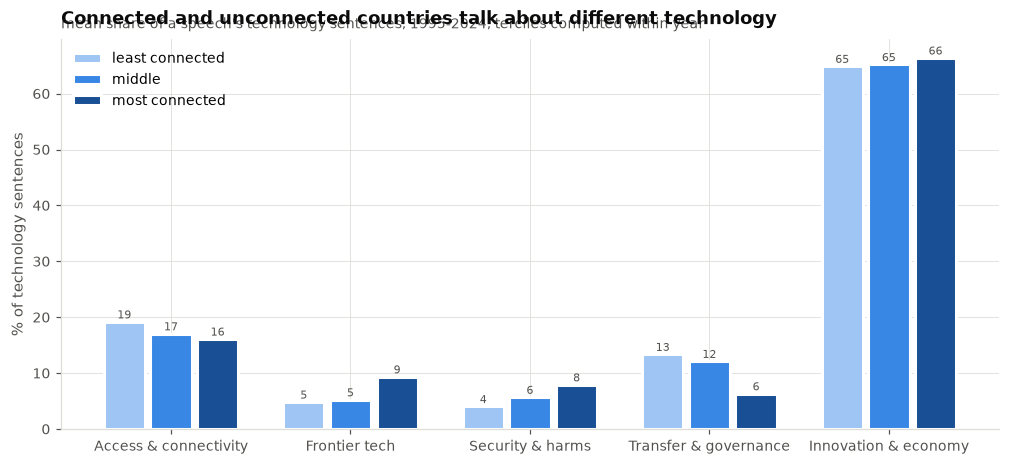

                      Access & connectivity  Frontier tech  Security & harms  Transfer & governance  Innovation & economy
connectivity_tercile                                                                                                     
least connected                      19.200          4.800             4.000                 13.400                64.900
middle                               17.100          5.200             5.700                 12.100                65.200
most connected                       16.100          9.400             7.900                  6.300                66.400


In [44]:
mix = (modern.dropna(subset=["connectivity_tercile"])
       .groupby("connectivity_tercile", observed=True)[[f"{f}_share" for f in FACETS]].mean())
mix.columns = [FACET_LABELS[c.replace("_share", "")] for c in mix.columns]

fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(len(mix.columns))
width = 0.26
for i, (label, row) in enumerate(mix.iterrows()):
    ax.bar(x + (i - 1) * width, 100 * row.values, width - 0.03,
           label=label, color=[SEQ_BLUE[1], SEQ_BLUE[3], SEQ_BLUE[5]][i],
           edgecolor="white", linewidth=2)
ax.set_xticks(x, mix.columns, fontsize=9)
finish(ax, "Connected and unconnected countries talk about different technology",
       "mean share of a speech's technology sentences, 1995-2024, terciles computed within year",
       ylabel="% of technology sentences")
for i, (label, row) in enumerate(mix.iterrows()):
    for j, v in enumerate(100 * row.values):
        ax.text(x[j] + (i - 1) * width, v + 0.6, f"{v:.0f}", ha="center",
                fontsize=7.5, color=INK_SOFT)
plt.show()

print((100 * mix).round(1).to_string())

In [52]:
compare = (modern.dropna(subset=["connectivity_tercile"])
           .groupby("connectivity_tercile", observed=True)
           .agg(speeches=("country_code", "size"),
                internet=("internet_users_pct", "mean"),
                salience=("tech_salience", "mean"),
                stance=("stance", "mean"),
                security=("tech_security_share", "mean"),
                governance=("tech_governance_share", "mean"),
                frontier=("tech_frontier_share", "mean"),
                trust_overlap=("trust_overlap", "mean")))
print(compare.round(3).to_string())

within = modern.copy()
within["internet_z"] = within.groupby("year")["internet_users_pct"].transform(
    lambda s: (s - s.mean()) / s.std())
cols = ["tech_salience", "tech_governance_share", "tech_access_share",
        "tech_frontier_share", "tech_security_share", "stance", "tech_vader", "log_gdp"]
rows = []
for c in cols:
    sub = within[["internet_z", c]].dropna()
    rows.append((c, len(sub), sub.corr().iloc[0, 1], sub.corr(method="spearman").iloc[0, 1]))
print("\ncorrelation with WITHIN-YEAR internet penetration (z-scored per year)\n")
print(pd.DataFrame(rows, columns=["feature", "n", "pearson_r", "spearman_rho"])
      .sort_values("pearson_r").to_string(index=False))

                      speeches  internet  salience  stance  security  governance  frontier  trust_overlap
connectivity_tercile                                                                                     
least connected           1800    11.692     0.015   0.185     0.040       0.134     0.048          0.034
middle                    1781    31.989     0.018   0.158     0.057       0.121     0.052          0.034
most connected            1789    58.653     0.019   0.127     0.079       0.063     0.094          0.049

correlation with WITHIN-YEAR internet penetration (z-scored per year)

              feature    n  pearson_r  spearman_rho
tech_governance_share 3154     -0.114        -0.104
               stance 3154     -0.066        -0.071
    tech_access_share 3154     -0.051        -0.030
           tech_vader 3154     -0.019        -0.028
        tech_salience 5370      0.042         0.033
  tech_security_share 3154      0.102         0.152
  tech_frontier_share 3154      0.

### The question we started from, answered directly

This analysis began as *"do countries that speak positively about technology end
up with more of it?"* Measured properly, the answer is **no - and if anything the
other way round.**

Within a given year the framing stance correlates **-0.07** with internet
penetration and VADER's technology sentiment **-0.02**. Neither is a usable
signal, and the sign is the interesting part: the countries most enthusiastic
about technology are disproportionately the ones that do not have it - the
least-connected tercile averages a stance of +0.185 against +0.127 for the most
connected. Enthusiasm is what you express about something you are still waiting
for, which is also why the optimism index in section 5 falls as the world gets
connected.

What *does* track connectivity is not the **tone** but the **subject** - which
facet of technology a country spends its sentences on. That is the signal the
predictive model in section 8 has to work with.

The gradient is consistent and it runs in opposite directions for different
facets. Relative to its contemporaries, a **poorly connected** country devotes
more of its technology talk to **transfer and governance** - the language of being
owed something - while a **well connected** country devotes more to **frontier
technology** and **security and harms**. The framing stance is slightly *more*
optimistic among the least connected: technology is still a promise if you do not
have it yet.

Note how small these correlations are individually (|r| ≈ 0.05-0.11) next to
log GDP per capita (r ≈ 0.80). Individually, no single discourse feature is a
useful predictor. The predictive section asks whether they are useful
*collectively*, and whether the full text beats the sum of these hand-built
parts.

In [ ]:
# we deleted things here

---
## 7. Technology and trust

The theme's other half. `technology x theme_trust` counts sentences that mention
technology *and* the vocabulary of trust, accountability, transparency,
credibility or disinformation in the same breath.

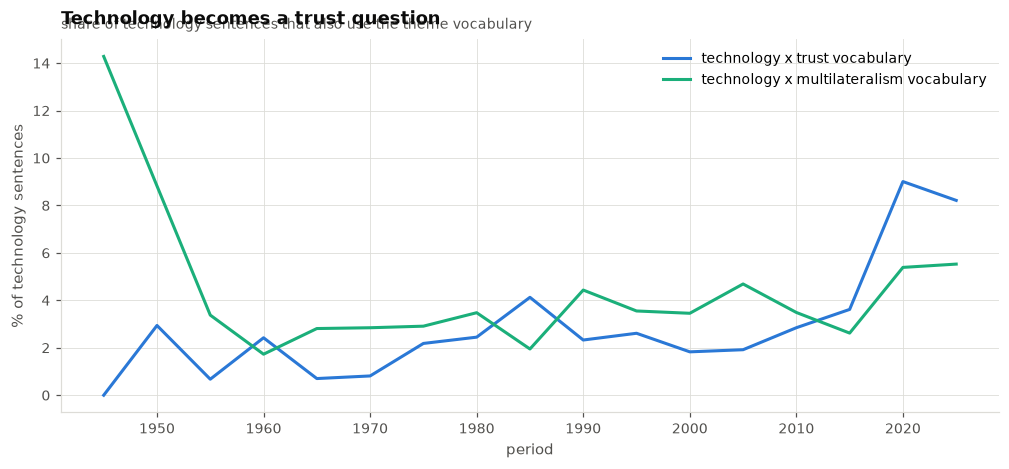

speeches matched to the World Happiness Report: 2,151
                     perceived_corruption  life_ladder   egdi  internet_users_pct
trust_overlap                      -0.031        0.130  0.161               0.234
tech_security_share                -0.020        0.120  0.250               0.295
stance                             -0.023       -0.057 -0.057              -0.026
tech_salience                      -0.063        0.052  0.057               0.118


In [ ]:
trust_year = features.assign(period=(features["year"] // 5) * 5).groupby("period").agg(
    tech=("technology_sentences", "sum"),
    trust_overlap=("technology_theme_trust_sentences", "sum"),
    multi_overlap=("technology_theme_transformation_sentences", "sum"))

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(trust_year.index, 100 * trust_year["trust_overlap"] / trust_year["tech"],
        color=BLUE, label="technology x trust vocabulary")
ax.plot(trust_year.index, 100 * trust_year["multi_overlap"] / trust_year["tech"],
        color=AQUA, label="technology x transformation vocabulary")
finish(ax, "Technology becomes a trust question",
       "share of technology sentences that also use the theme vocabulary",
       xlabel="period", ylabel="% of technology sentences")
plt.show()

trust_panel = modern.dropna(subset=["perceived_corruption"])
print(f"speeches matched to the World Happiness Report: {len(trust_panel):,}")
print(trust_panel[["trust_overlap", "tech_security_share", "stance", "tech_salience",
                   "perceived_corruption", "life_ladder", "egdi", "internet_users_pct"]]
      .corr(method="spearman").round(3)
      .loc[["trust_overlap", "tech_security_share", "stance", "tech_salience"],
           ["perceived_corruption", "life_ladder", "egdi", "internet_users_pct"]].to_string())

Technology and trust were barely mentioned in the same breath until the 2000s;
the overlap has roughly tripled since, and is at its highest in the last two
periods. That is the theme's two halves colliding inside one SDG.

The cross-sectional correlations are weak but consistently signed: countries that
talk about technology in the language of trust and harm are the ones that are
**more** connected and score **higher** on e-government (rho 0.23 and 0.25 against
internet users and EGDI), not the ones with worse governance. Perceived
corruption is essentially uncorrelated with any of it (|rho| < 0.07). Talking
about digital trust is a symptom of having a digital society to worry about, not
of distrust in general.

---
## 8. Predictive question: can a speech tell us how connected a country is?

> **Target.** `internet_users_pct` - individuals using the Internet, % of
> population (World Bank `IT.NET.USER.ZS`), in the same year as the speech.
> 5,370 speeches, 194 countries, 1995-2025. Mean 34.1%, sd 32.7%.

**The validation design matters more than the model here.** A random split would
put Norway 2011 in the training set and Norway 2012 in the test set, and any
model would score brilliantly by memorising which country it is reading. Two
honest protocols are used instead:

1. **`GroupKFold` by country (5 folds)** - every speech by a country is in the
   same fold, so the test question is *"here is a country you have never read,
   how connected is it?"*
2. **Temporal holdout** - train on 1995-2014, test on 2015-2024. *"Here is a
   year you have never seen."*

**The comparison that answers the question** is nested: `year + log GDP per
capita` is what you could predict without reading anything. Whatever the text
adds on top of that is what the speech actually knows.

In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

tokens = pd.read_csv(OUT_DIR / "speeches_text.csv.gz", usecols=["country_code", "year", "tokens_clean"])

TECH_FEATURES = [
    "tech_salience", "tech_intensity",
    "tech_access_share", "tech_frontier_share", "tech_security_share",
    "tech_governance_share", "tech_economy_share",
    "promise_share", "peril_share", "stance",
    "tech_tone", "tech_tone_rel", "tech_vader",
    "trust_overlap", "multilateral_overlap", "trust_salience",
    "lexical_density", "mean_sentence_length", "n_sentences",
]

design = (modern.merge(tokens, on=["country_code", "year"], how="left")
          .dropna(subset=["internet_users_pct"]).reset_index(drop=True))
design[TECH_FEATURES] = design[TECH_FEATURES].fillna(0.0)
design["text"] = design["tokens_clean"].fillna("")

y = design["internet_users_pct"].to_numpy()
groups = design["country_code"].to_numpy()
cv = GroupKFold(n_splits=5)

print(f"{len(design):,} speeches | {design['country_code'].nunique()} countries | "
      f"{design['year'].min()}-{design['year'].max()}")
print(f"target: mean {y.mean():.1f}%, sd {y.std():.1f}%, range {y.min():.1f}-{y.max():.1f}%")

5,370 speeches | 194 countries | 1995-2025
target: mean 34.1%, sd 32.7%, range 0.0-100.0%


In [67]:
def make_model(numeric=(), use_text=False, estimator=None):
    """Ridge over a standardised numeric block, optionally plus TF-IDF of the speech."""
    blocks = []
    if numeric:
        blocks.append(("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                                        ("scale", StandardScaler())]), list(numeric)))
    if use_text:
        blocks.append(("text", TfidfVectorizer(min_df=15, max_df=0.6, ngram_range=(1, 2),
                                               sublinear_tf=True), "text"))
    estimator = estimator or RidgeCV(alphas=np.logspace(-1, 4, 20))
    return Pipeline([("features", ColumnTransformer(blocks)), ("model", estimator)])


def evaluate(name, model, X=None):
    pred = cross_val_predict(model, X if X is not None else design, y, cv=cv, groups=groups)
    return {"model": name, "R2": r2_score(y, pred),
            "RMSE": root_mean_squared_error(y, pred),
            "MAE": mean_absolute_error(y, pred)}, pred


results, preds = [], {}
specs = [
    ("0. baseline: predict the mean", make_model(["year"], estimator=DummyRegressor())),
    ("1. year only", make_model(["year"])),
    ("2. year + technology features (ridge)", make_model(["year"] + TECH_FEATURES)),
    ("3. year + technology features (boosted trees)",
     make_model(["year"] + TECH_FEATURES, estimator=HistGradientBoostingRegressor(random_state=0))),
    ("4. year + full speech TF-IDF (ridge)", make_model(["year"], use_text=True)),
    ("5. reference: year + log GDP per capita (no text)", make_model(["year", "log_gdp"])),
    ("6. year + log GDP + technology features", make_model(["year", "log_gdp"] + TECH_FEATURES)),
    ("7. year + log GDP + TF-IDF", make_model(["year", "log_gdp"], use_text=True)),
]
for name, model in specs:                      # ~4 minutes in total
    row, pred = evaluate(name, model)
    results.append(row)
    preds[name] = pred
    print(f"{row['model']:<50s} R2={row['R2']:+.3f}  RMSE={row['RMSE']:5.2f}  MAE={row['MAE']:5.2f}")

scores = pd.DataFrame(results).set_index("model")

0. baseline: predict the mean                      R2=-0.003  RMSE=32.78  MAE=29.14
1. year only                                       R2=+0.478  RMSE=23.64  MAE=18.81
2. year + technology features (ridge)              R2=+0.528  RMSE=22.49  MAE=17.86
3. year + technology features (boosted trees)      R2=+0.530  RMSE=22.44  MAE=16.90
4. year + full speech TF-IDF (ridge)               R2=+0.761  RMSE=16.01  MAE=12.45
5. reference: year + log GDP per capita (no text)  R2=+0.791  RMSE=14.97  MAE=11.87
6. year + log GDP + technology features            R2=+0.795  RMSE=14.81  MAE=11.81
7. year + log GDP + TF-IDF                         R2=+0.835  RMSE=13.29  MAE=10.44


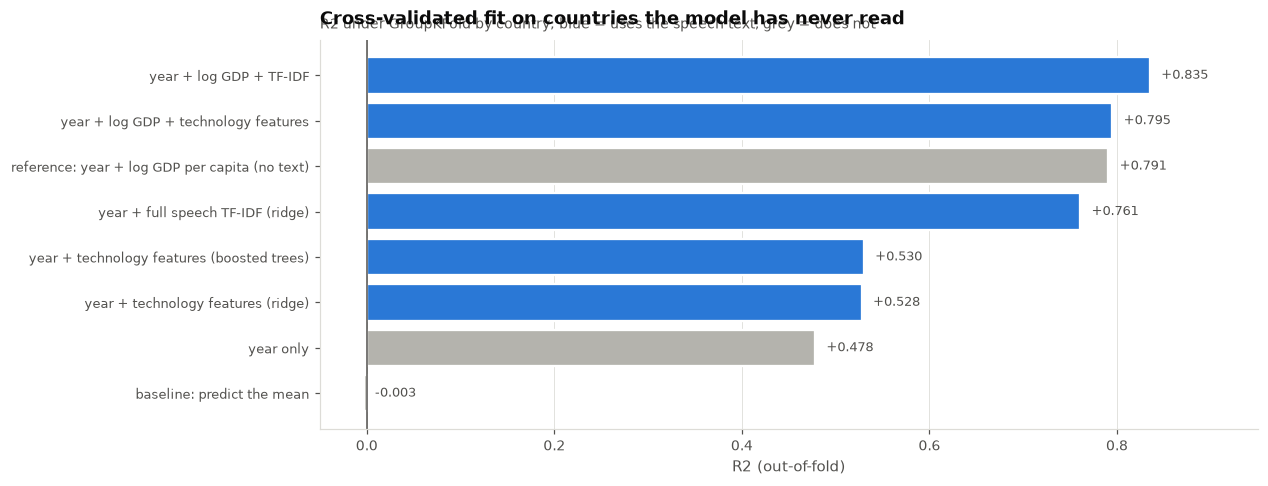

                                                      R2   RMSE    MAE
model                                                                 
0. baseline: predict the mean                     -0.003 32.784 29.139
1. year only                                       0.478 23.645 18.815
2. year + technology features (ridge)              0.528 22.490 17.857
3. year + technology features (boosted trees)      0.530 22.436 16.903
4. year + full speech TF-IDF (ridge)               0.761 16.005 12.453
5. reference: year + log GDP per capita (no text)  0.791 14.969 11.869
6. year + log GDP + technology features            0.795 14.814 11.807
7. year + log GDP + TF-IDF                         0.835 13.288 10.441


In [68]:
fig, ax = plt.subplots(figsize=(11, 4.6))
order = scores.sort_values("R2")
is_text = [("TF-IDF" in m) or ("technology features" in m) for m in order.index]
ax.barh(range(len(order)), order["R2"],
        color=[BLUE if t else "#b4b3ad" for t in is_text],
        edgecolor="white", linewidth=1.5)
ax.set_yticks(range(len(order)), [m[3:] for m in order.index], fontsize=8.5)
for i, v in enumerate(order["R2"]):
    ax.text(v + 0.012, i, f"{v:+.3f}", va="center", fontsize=8.5, color=INK_SOFT)
ax.axvline(0, color=INK_SOFT, lw=1)
finish(ax, "Cross-validated fit on countries the model has never read",
       "R2 under GroupKFold by country; blue = uses the speech text, grey = does not",
       xlabel="R2 (out-of-fold)", legend=False)
ax.grid(axis="y", visible=False)
ax.set_xlim(-0.05, 0.95)
plt.show()

print(scores.round(3).to_string())

**Reading the table.**

- Speech text alone (model 4, `year + TF-IDF`) reaches **R² = 0.76** on countries
  the model has never seen, against 0.48 for the year alone and -0.00 for the
  mean. A General Debate statement carries most of the information in a country's
  connectivity rate.
- The hand-built technology features (model 2) reach **0.53** - five points of R²
  over the time trend, so they are real, but the full bag of words is far
  stronger. The signal is not confined to the technology vocabulary we chose. The
  boosted-tree version (model 3) scores the same as the linear one, so whatever
  is in those features is close to additive.
- The honest test is **5 vs 7**: adding the text to `year + log GDP per capita`
  moves R² from **0.791 to 0.835** and RMSE from 15.0 to 13.3 percentage points.
  The speech carries information about connectivity that national income and the
  calendar do not.
- Model 6 is the same comparison for the engineered features alone: +0.004 R² on
  top of income and year. Ten times less than the full text buys. Hand-built
  topic features are good for *explaining*; the bag of words is what predicts.

In [69]:
# Protocol 2: train on the past, predict the future.
train = design["year"] <= 2014
best = make_model(["year", "log_gdp"], use_text=True)
best.fit(design[train], y[train])
future = best.predict(design[~train])

gdp_only = make_model(["year", "log_gdp"]).fit(design[train], y[train]).predict(design[~train])
print(f"temporal holdout: train {train.sum():,} speeches (1995-2014), "
      f"test {(~train).sum():,} speeches (2015-2024)\n")
for label, pred in [("year + log GDP (no text)", gdp_only), ("year + log GDP + TF-IDF", future)]:
    print(f"  {label:<26s} R2={r2_score(y[~train], pred):+.3f}  "
          f"RMSE={root_mean_squared_error(y[~train], pred):5.2f}  "
          f"MAE={mean_absolute_error(y[~train], pred):5.2f}")

temporal holdout: train 3,548 speeches (1995-2014), test 1,822 speeches (2015-2024)

  year + log GDP (no text)   R2=+0.671  RMSE=16.24  MAE=13.93
  year + log GDP + TF-IDF    R2=+0.716  RMSE=15.08  MAE=12.28


/var/folders/w3/46_xdj516njc_dhpyr7slfjr0000gn/T/ipykernel_63133/1670547240.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot([resid.loc[resid["region"] == r, "residual"] for r in order],


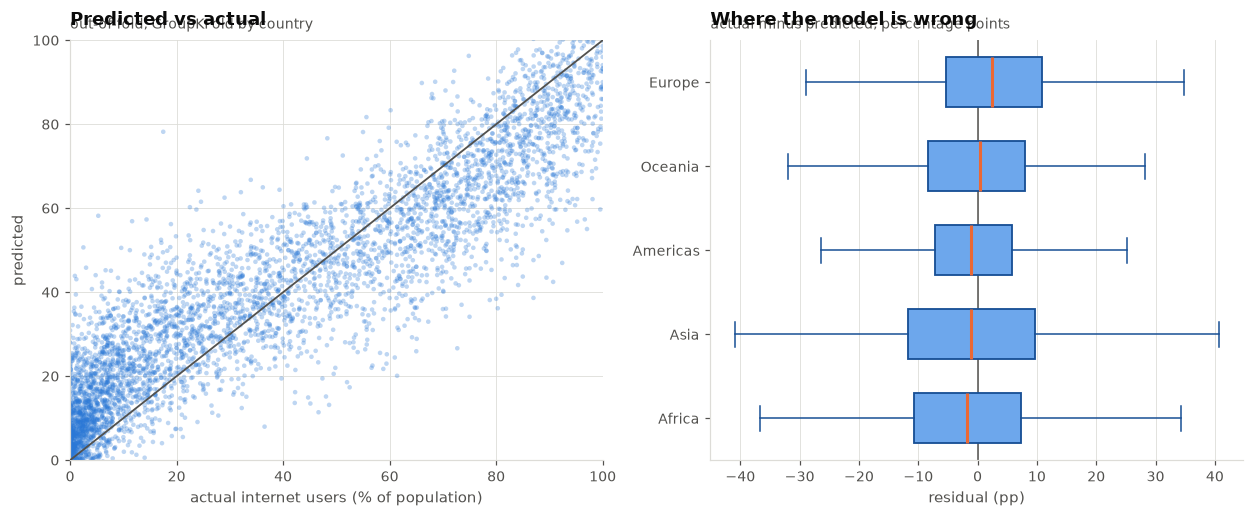

          count   mean  median    std
region                               
Africa     1486 -1.810  -1.840 13.250
Americas   1031 -0.170  -1.130 10.160
Asia       1299 -1.020  -1.160 15.060
Europe     1239  3.380   2.440 13.160
Oceania     315  0.070   0.370 12.890


In [70]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
pred = preds["7. year + log GDP + TF-IDF"]

axes[0].scatter(y, pred, s=9, alpha=0.30, color=BLUE, edgecolor="none")
lims = (0, 100)
axes[0].plot(lims, lims, color=INK_SOFT, lw=1.2, zorder=3)
axes[0].set_xlim(*lims); axes[0].set_ylim(*lims)
finish(axes[0], "Predicted vs actual", "out-of-fold, GroupKFold by country",
       xlabel="actual internet users (% of population)",
       ylabel="predicted", legend=False)

resid = pd.DataFrame({"region": design["region_name"], "residual": y - pred}).dropna()
order = resid.groupby("region")["residual"].median().sort_values().index
axes[1].axvline(0, color=INK_SOFT, lw=1)
axes[1].boxplot([resid.loc[resid["region"] == r, "residual"] for r in order],
                vert=False, widths=0.6, patch_artist=True, showfliers=False,
                boxprops=dict(facecolor=SEQ_BLUE[2], edgecolor=SEQ_BLUE[5], linewidth=1.2),
                medianprops=dict(color=ORANGE, linewidth=2),
                whiskerprops=dict(color=SEQ_BLUE[5]), capprops=dict(color=SEQ_BLUE[5]))
axes[1].set_yticks(range(1, len(order) + 1), order, fontsize=9)
finish(axes[1], "Where the model is wrong", "actual minus predicted, percentage points",
       xlabel="residual (pp)", legend=False)
axes[1].grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print(resid.groupby("region")["residual"].agg(["count", "mean", "median", "std"]).round(2).to_string())

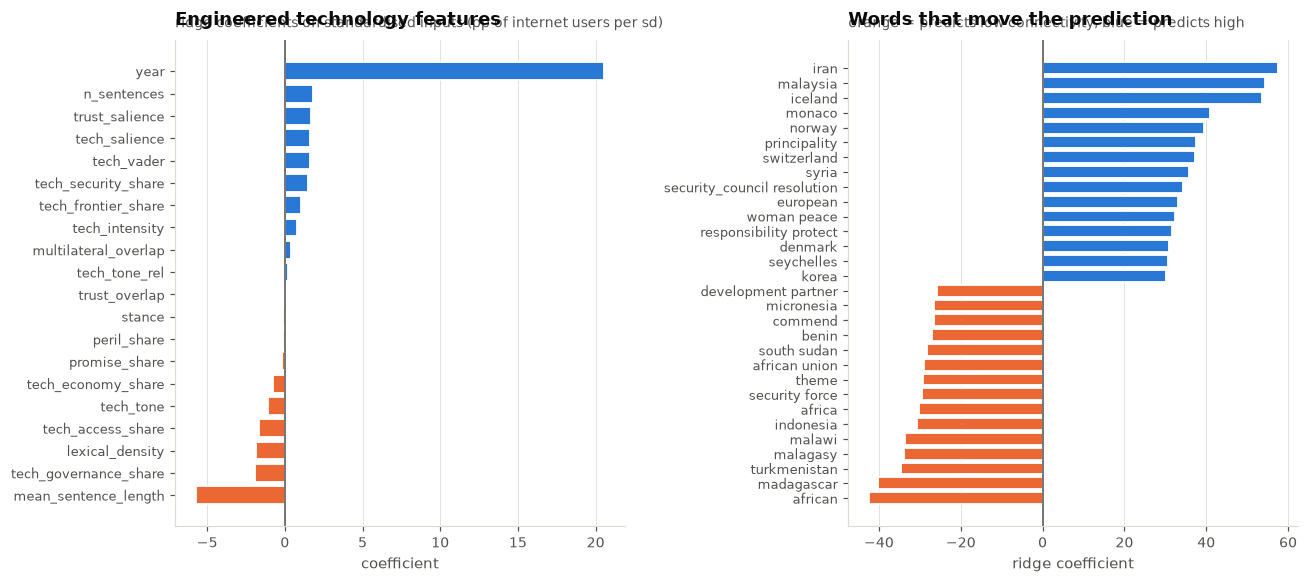

mean_sentence_length    -5.742
tech_governance_share   -1.920
lexical_density         -1.834
tech_access_share       -1.644
tech_tone               -1.087
tech_economy_share      -0.750
promise_share           -0.204
peril_share             -0.122
stance                  -0.107
trust_overlap            0.083
tech_tone_rel            0.178
multilateral_overlap     0.404
tech_intensity           0.784
tech_frontier_share      1.070
tech_security_share      1.509
tech_vader               1.640
tech_salience            1.643
trust_salience           1.674
n_sentences              1.833
year                    20.566


In [71]:
# What does the model read? Standardised ridge coefficients on the engineered block...
interpretable = make_model(["year"] + TECH_FEATURES, estimator=RidgeCV(alphas=np.logspace(-1, 4, 20)))
interpretable.fit(design, y)
coefs = pd.Series(interpretable.named_steps["model"].coef_,
                  index=["year"] + TECH_FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
axes[0].barh(range(len(coefs)), coefs.values,
             color=[BLUE if v > 0 else ORANGE for v in coefs.values],
             edgecolor="white", linewidth=1.2)
axes[0].set_yticks(range(len(coefs)), coefs.index, fontsize=8.5)
axes[0].axvline(0, color=INK_SOFT, lw=1)
finish(axes[0], "Engineered technology features",
       "ridge coefficients on standardised inputs (pp of internet users per sd)",
       xlabel="coefficient", legend=False)
axes[0].grid(axis="y", visible=False)

# ...and the strongest words in the TF-IDF model.
text_model = make_model(["year"], use_text=True).fit(design, y)
vocab = text_model.named_steps["features"].named_transformers_["text"].get_feature_names_out()
word_coef = pd.Series(text_model.named_steps["model"].coef_[1:], index=vocab)
extreme = pd.concat([word_coef.nsmallest(15), word_coef.nlargest(15)]).sort_values()
axes[1].barh(range(len(extreme)), extreme.values,
             color=[ORANGE if v < 0 else BLUE for v in extreme.values],
             edgecolor="white", linewidth=1.2)
axes[1].set_yticks(range(len(extreme)), extreme.index, fontsize=8.5)
axes[1].axvline(0, color=INK_SOFT, lw=1)
finish(axes[1], "Words that move the prediction",
       "orange = predicts low connectivity, blue = predicts high",
       xlabel="ridge coefficient", legend=False)
axes[1].grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print(coefs.round(3).to_string())

The engineered coefficients recover the discourse divide from the EDA with the
sign we expect: `tech_governance_share` (technology transfer) and `peril_share`
push the prediction **down**, `tech_frontier_share`, `tech_security_share` and
`tech_salience` push it **up**. `tech_vader` sits near zero - general-purpose
sentiment carries almost no information about connectivity, while the
facet composition carries a lot.

The word-level coefficients are the reason for §8.1: **23 of the 30 words shown
here are place names**, which looks exactly like a model that has learned to
recognise countries rather than read speeches. It has not, but that takes a
deliberate test to establish, and the test is the next section.

Setting the place names aside, the word-level coefficients are a useful reality
check on what the bag of words is really doing: alongside genuine technology vocabulary it picks up the
**register of development diplomacy** in general. That is not cheating - it is a
real correlate - but it is why the text model should be read as "this speech
sounds like a country at *that* level of development", not as "this country's
technology policy is good".

### 8.1 Is the model reading the speech, or the letterhead?

Look again at the word coefficients. `iran`, `iceland`, `monaco`, `malaysia`,
`turkmenistan`, `madagascar`, `malagasy`, `african`, `micronesia` - **23 of the
30 strongest features are place names**. That is worth stopping over, because
**98.7% of speeches name their own country**, and the corpus names every other
country too. The worry has a precise form:

> `GroupKFold` by country is supposed to make the test question *"here is a
> country you have never read."* But the model can learn what Iceland is like
> from the **other** speeches in the corpus that mention Iceland, and then
> recognise Iceland's own held-out speech by its name. The fold structure cannot
> stop that, because the country name is a **feature**, not a group label.

If that is what is happening, R² = 0.835 is a country lookup table wearing a
model's clothes, and the honest score is much lower. The test is to take the
names away and refit.

`geonames.py` builds the blocklists from the same UNSD M49 file the rest of the
pipeline uses for regions, expanded with the regular demonym suffixes
(*Kenya* → *Kenyan*, *Rwanda* → *Rwandese*, *Iraq* → *Iraqi*) and a hand-written
list of the irregular ones no rule produces (*French*, *Dutch*, *Swiss*,
*Malagasy*, *Burkinabe*), plus historical names the speeches still use
(*Soviet*, *Yugoslavia*, *Zaire*, *Burma*, *Ceylon*). Tokens that only *look*
geographic are kept: "Holy See" must not cost us `see`, "Isle of Man" must not
cost us `man`, "Great Britain" must not cost us `great`, and "West Bank" must
not cost us `bank`.

Four levels of text, each strictly inside the next:

| level | what is removed | answers |
|---|---|---|
| **raw** | nothing | the original §8 number |
| **own country** | only the speaker's own names and demonyms | is it just reading the letterhead? |
| **country** | every country name and demonym, from any speaker | can it still identify the country at all? |
| **geography** | + regions, capitals, regional bodies, state-form titles | is any *where* left in the text? |

In [ ]:
from un_general_debate_analysis.geonames import (
    country_blocklist, geo_blocklist, own_country_blocklist, scrub_series)

design["text_self"] = scrub_series(design["text"], frozenset(), design["country_code"])
design["text_country"] = scrub_series(design["text"], country_blocklist())
design["text_geo"] = scrub_series(design["text"], geo_blocklist())
# The complement of the strictest level: the place names on their own, so we can
# ask what they are worth by themselves rather than only what their absence costs.
GEO = geo_blocklist()
design["text_geo_only"] = design["text"].map(
    lambda t: " ".join(w for w in t.split() if w in GEO))

VARIANTS = [("text", "raw text"), ("text_self", "own country removed"),
            ("text_country", "all country names removed"),
            ("text_geo", "all geography removed")]

raw_tokens = design["text"].str.split().str.len().sum()
print(f"{len(design):,} speeches, {raw_tokens:,} tokens\n")
for col, label in VARIANTS + [("text_geo_only", "ONLY the place names")]:
    n = design[col].str.split().str.len().sum()
    print(f"  {label:<26} {n:>10,} tokens   {100 * n / raw_tokens:5.1f}% of raw")

own = own_country_blocklist()
names_own = design["text"].map(lambda t: set(t.split())) \
    .combine(design["country_code"], lambda words, c: bool(words & own.get(c, frozenset())))
print(f"\nspeeches that name their own country: {names_own.mean():.1%}")

example = design[(design["country_code"] == "KEN") & (design["year"] == 2019)].iloc[0]
dropped = sorted({w for w in example["text"].split() if w in GEO})
print(f"\nKenya 2019 - {len(dropped)} distinct place words removed:\n  " + ", ".join(dropped))

In [ ]:
def make_text_model(numeric, text_col):
    """Section 8's builder, with the text column chosen per variant."""
    return Pipeline([
        ("features", ColumnTransformer([
            ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                              ("scale", StandardScaler())]), list(numeric)),
            ("text", TfidfVectorizer(min_df=15, max_df=0.6, ngram_range=(1, 2),
                                     sublinear_tf=True), text_col)])),
        ("model", RidgeCV(alphas=np.logspace(-1, 4, 20)))])


# ~10 minutes: ten TF-IDF ridges, each cross-validated over five country folds.
scrub_rows = []
for numeric, block in [(["year"], "year"), (["year", "log_gdp"], "year + log GDP")]:
    print(f"--- {block} + TF-IDF ---")
    for col, label in VARIANTS + [("text_geo_only", "ONLY the place names")]:
        pred = cross_val_predict(make_text_model(numeric, col), design, y,
                                 cv=cv, groups=groups)
        scrub_rows.append({"controls": block, "text": label, "R2": r2_score(y, pred),
                           "RMSE": root_mean_squared_error(y, pred),
                           "MAE": mean_absolute_error(y, pred)})
        print(f"  {label:<26} R2={scrub_rows[-1]['R2']:+.3f}  "
              f"RMSE={scrub_rows[-1]['RMSE']:5.2f}  MAE={scrub_rows[-1]['MAE']:5.2f}")

scrub_scores = pd.DataFrame(scrub_rows)
no_text = {"year": scores.loc["1. year only", "R2"],
           "year + log GDP": scores.loc["5. reference: year + log GDP per capita (no text)", "R2"]}
print("\nno-text reference points: " + ", ".join(f"{k} = {v:+.3f}" for k, v in no_text.items()))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), sharex=True)
LABEL_ORDER = ["raw text", "own country removed", "all country names removed",
               "all geography removed", "ONLY the place names"]
BARS = [BLUE, SEQ_BLUE[4], SEQ_BLUE[3], SEQ_BLUE[2], ORANGE]

for ax, block in zip(axes, ["year", "year + log GDP"]):
    sub = scrub_scores[scrub_scores["controls"] == block].set_index("text").loc[LABEL_ORDER]
    ax.barh(range(len(sub)), sub["R2"], color=BARS, edgecolor="white", linewidth=1.5)
    ax.set_yticks(range(len(sub)), sub.index, fontsize=8.5)
    ax.invert_yaxis()
    ax.axvline(no_text[block], color=INK_SOFT, lw=1.2, ls="--",
               label=f"{block}, no text ({no_text[block]:+.3f})")
    for i, v in enumerate(sub["R2"]):
        ax.text(v - 0.01, i, f"{v:+.3f}", va="center", ha="right",
                fontsize=8.5, color="white", fontweight="bold")
    finish(ax, f"{block} + TF-IDF",
           "out-of-fold R2, GroupKFold by country", xlabel="R2")
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, 0.92)
plt.tight_layout()
plt.show()

print(scrub_scores.pivot(index="text", columns="controls", values="R2")
      .loc[LABEL_ORDER].round(3).to_string())

# Protocol 2 again: does the temporal holdout agree?
print("\ntemporal holdout (train 1995-2014, test 2015-2024), year + log GDP + TF-IDF\n")
train = design["year"] <= 2014
for col, label in VARIANTS:
    fitted = make_text_model(["year", "log_gdp"], col).fit(design[train], y[train])
    held = fitted.predict(design[~train])
    print(f"  {label:<26} R2={r2_score(y[~train], held):+.3f}  "
          f"RMSE={root_mean_squared_error(y[~train], held):5.2f}")

In [ ]:
# What is left for the model to read once every place name is gone?
scrubbed = make_text_model(["year"], "text_geo").fit(design, y)
scrub_vocab = scrubbed.named_steps["features"].named_transformers_["text"].get_feature_names_out()
scrub_coef = pd.Series(scrubbed.named_steps["model"].coef_[1:], index=scrub_vocab)
extreme = pd.concat([scrub_coef.nsmallest(18), scrub_coef.nlargest(18)]).sort_values()

fig, ax = plt.subplots(figsize=(9.5, 6.4))
ax.barh(range(len(extreme)), extreme.values,
        color=[ORANGE if v < 0 else BLUE for v in extreme.values],
        edgecolor="white", linewidth=1.2)
ax.set_yticks(range(len(extreme)), extreme.index, fontsize=8.5)
ax.axvline(0, color=INK_SOFT, lw=1)
finish(ax, "The same prediction, with no place names left",
       "ridge coefficients on geography-scrubbed text; "
       "orange = predicts low connectivity, blue = predicts high",
       xlabel="ridge coefficient", legend=False)
ax.grid(axis="y", visible=False)
plt.show()

### What the scrub says

**The hypothesis is wrong, and it is worth being explicit about that.** Taking
the country names out does not cost the model anything:

| text the model sees | year + TF-IDF | year + log GDP + TF-IDF |
|---|---|---|
| raw | 0.761 | 0.835 |
| own country removed | **0.776** | **0.837** |
| all country names removed | 0.768 | 0.834 |
| all geography removed | 0.766 | 0.834 |
| *only* the place names | 0.510 | 0.768 |

Four things follow, and the last one is the methodological point.

1. **Removing the speaker's own country name makes the model slightly
   *better*** (0.761 → 0.776). Whatever the name was contributing, it was noise,
   not signal - consistent with a rare, high-variance feature that ridge cannot
   fully shrink.
2. **Stripping every place name in the world costs nothing measurable.** Against
   the year it *gains* 0.005 (0.761 → 0.766); on top of income it loses 0.001
   (0.835 → 0.834); in the temporal holdout it loses 0.003 (0.716 → 0.713).
   All three are inside fold noise, and the §8 headline survives intact.
3. **The place names on their own are nearly worthless**, which is the direct
   test rather than the indirect one. A TF-IDF built from *only* the 4.9% of
   tokens that are place names scores 0.510 against 0.478 for the year alone -
   **+0.032 R²**, where the full text buys **+0.283**. Added to income and the
   year they are worth *less than nothing*: 0.768 against 0.791 for income and
   the year by themselves.
4. **A large ridge coefficient is not evidence of reliance.** `iran` and
   `iceland` had two of the biggest weights in the model and removing them
   changed nothing, because a feature that is large but almost always zero moves
   almost no predictions. Coefficient size ranks *features*; it does not measure
   *contribution*. The only way to find out what a feature is worth is to delete
   it and refit.

So the signal is **redundant and distributed**. The chart above is what the
model reads when geography is gone, and it is the §6 discourse divide in plain
words: `rural`, `drought`, `cyclone`, `village`, `socioeconomic`,
`development partner`, `development plan` and `defence security` predict low
connectivity; `security_council resolution`, `responsibility protect`,
`effective multilateralism`, `international_law`, `nuclear programme`,
`renewable` and `carbon` predict high. The country name was never doing the
work - the *register of development diplomacy* was, and it is spread across
hundreds of words that no blocklist can remove without deleting the speech.

**Two honest limits.** The scrub is a blocklist, so it is only as complete as
its vocabulary; and it cannot remove what is geographic without being a name.
`island forum`, `basin` and `geothermal` survive it, as does `prince`, which
marks a monarchy. Those are proxies for identity, and they
are the reason the right reading of §8 stays the one stated above: the text
model says *"this speech sounds like a country at that level of development"*,
not *"this country's technology policy is good"*.

---
## 9. Does talk come before action?

The model above reads the *present*. The sharper question is whether technology
discourse is a **leading indicator**: given what a country says in year *t*, can
we predict how much its internet penetration grows by *t+5*, beyond what its
current level and income already imply?

> **Target.** `internet_users_pct[t+5] - internet_users_pct[t]`, in percentage
> points. Speeches 1998-2018 so that the outcome exists. Mean growth +13.7 pp.

In [72]:
future_net = (external[["country_code", "year", "internet_users_pct"]]
              .assign(year=lambda f: f["year"] - 5)
              .rename(columns={"internet_users_pct": "internet_in_5y"}))

growth = (design.merge(future_net, on=["country_code", "year"], how="inner")
          .query("1998 <= year <= 2018")
          .dropna(subset=["internet_users_pct", "internet_in_5y"])
          .reset_index(drop=True))
growth["growth_5y"] = growth["internet_in_5y"] - growth["internet_users_pct"]

y_g = growth["growth_5y"].to_numpy()
groups_g = growth["country_code"].to_numpy()
print(f"{len(growth):,} speeches | {growth['country_code'].nunique()} countries | "
      f"{growth['year'].min()}-{growth['year'].max()}")
print(f"5-year growth: mean {y_g.mean():+.1f} pp, sd {y_g.std():.1f} pp\n")

CONTROLS = ["year", "internet_users_pct", "log_gdp"]
growth_specs = [
    ("baseline: predict the mean", make_model(CONTROLS, estimator=DummyRegressor())),
    ("controls: year + current level + log GDP", make_model(CONTROLS)),
    ("controls + technology features", make_model(CONTROLS + TECH_FEATURES)),
    ("controls + full speech TF-IDF", make_model(CONTROLS, use_text=True)),
    ("text only (no level, no GDP)", make_model(["year"] + TECH_FEATURES, use_text=True)),
]
growth_rows = []
for name, model in growth_specs:               # ~2 minutes
    pred = cross_val_predict(model, growth, y_g, cv=cv, groups=groups_g)
    growth_rows.append({"model": name, "R2": r2_score(y_g, pred),
                        "RMSE": root_mean_squared_error(y_g, pred),
                        "MAE": mean_absolute_error(y_g, pred)})
    print(f"  {name:<44s} R2={growth_rows[-1]['R2']:+.3f}  "
          f"RMSE={growth_rows[-1]['RMSE']:5.2f}  MAE={growth_rows[-1]['MAE']:5.2f}")

growth_scores = pd.DataFrame(growth_rows).set_index("model")

3,758 speeches | 193 countries | 1998-2018
5-year growth: mean +13.7 pp, sd 10.9 pp

  baseline: predict the mean                   R2=-0.003  RMSE=10.92  MAE= 8.74
  controls: year + current level + log GDP     R2=+0.266  RMSE= 9.34  MAE= 7.14
  controls + technology features               R2=+0.260  RMSE= 9.38  MAE= 7.20
  controls + full speech TF-IDF                R2=+0.294  RMSE= 9.16  MAE= 7.05
  text only (no level, no GDP)                 R2=+0.172  RMSE= 9.92  MAE= 7.63


**Answer: a little, but only a little.** The controls alone reach R² = 0.266;
adding the full speech text takes it to 0.294. The hand-built technology features
make it *slightly worse* (0.260), and text alone manages 0.172.

That asymmetry is itself the finding. The same text that explains **83.5%** of the
variance in where a country *is* adds **under 3 points** to a forecast of where it
is *going*. General Debate speeches are an excellent description of a country's
present condition and a weak forecast of its trajectory - which is roughly what
one should expect of an annual political statement, and a useful corrective to
the assumption that rhetoric leads policy.

---
## 11. What we found

**Exploratory question.**

1. **Technology went from a footnote to a fixture.** Around a tenth of speeches
   mentioned it in 1950; **87% do in 2025**, and it takes twenty-five times more
   of the average speech than it did then.
2. **The subject changed twice.** *Transfer* (1960-85, up to a third of mentions
   are technology transfer and "science and technology"), then *access*
   (1995-2010, the internet and the digital divide, peaking around WSIS), then
   *risk* (2015-2025: the security-and-harms facet goes from ~1% to 14% of
   mentions, and frontier technology - essentially AI - reaches 23% in 2025).
3. **Optimism is at its lowest recorded level.** The promise-minus-peril index
   falls from +29 points in the late 1940s and +30 in the early 1960s to **+5.7
   in 2025**. The independent, high-precision measure - the share of technology
   sentences that name an actual technological harm - went from under 1% before
   2005 to 16% in 2020-24. This is the SDG 9 face of *"restoring trust"*: the
   transformation states are managing is one they have stopped trusting.
4. **Off-the-shelf sentiment cannot see any of this.** VADER's technology
   sentiment is flat across eighty years, because its lexicon contains no
   *cyberattack*, no *disinformation*, no *deepfake*. Domain dictionaries were
   necessary, not decorative.
5. **The digital divide is a discourse divide.** Within any given year, the
   least-connected tercile of countries spends more of its technology talk on
   transfer and governance; the most-connected tercile spends more on frontier
   technology and on harms. Same word, opposite conversation.

**Predictive question.**

6. A ridge regression on the speech text predicts a country's internet
   penetration at **R² = 0.76 on countries it has never read**, and **0.835** when
   national income and the year are added - **4.4 points of R² beyond what income
   and the calendar already explain**, worth 1.7 pp of RMSE. The same gain shows
   up in the temporal holdout (0.671 → 0.716 on 2015-2024), so it is not an
   artefact of one split. **It is also not the country names**: 23 of the 30
   strongest word features are place names, but deleting every country name,
   demonym, region, capital and regional body from the corpus moves R² from
   0.835 to 0.834, and place names on their own are worth +0.03 R² where the
   full text is worth +0.28 (§8.1). The signal is the register of development
   diplomacy, spread redundantly across the whole speech.
7. The same text predicts the *next five years* of connectivity growth far less
   well: R² 0.266 → 0.294 over controls.
8. **On investment, the gap is total.** Speech text predicts R&D intensity five
   years out at R² 0.47 - but the horizon test shows that number is **flat at
   t+0, t+5 and t+10** and collapses to **-0.06** on the five-year change, and the
   direction of change is a near-coin-flip (**AUC 0.58** against a 61% base rate).
   The text is measuring the present, not forecasting.

**The through-line.** Across three different outcomes - connectivity level,
connectivity growth, research spending - General Debate speeches are a strong
*description* of where a country is and a weak *prediction* of where it is going.
For the theme, that is the uncomfortable part of "managing transformation":
what states say at this podium tracks their circumstances closely and their
trajectory barely at all.

### Limitations

- **Dictionaries are not classifiers.** The hand audit put promise-framing
  precision at ~85% and peril-framing at ~65-70%; the peril errors come from
  threat-list sentences where technology is one item among several. The
  `tech_security` facet is reported alongside as the high-precision check, and
  the two agree on direction.
- **Session 80 (2025) is a different instrument.** The UN published no validated
  transcripts, so the whole session was transcribed from interpretation audio
  with Whisper. Every 2025 value here should be read as indicative. The 2015-2024
  trends do not depend on it.
- **The R&D panel is a selected sample.** Only 107 countries report R&D spending,
  and they are richer and more research-active than the rest. §10 generalises to
  countries that measure their own research, not to the membership.
- **A persistent target flatters a model.** R&D intensity has a five-year
  autocorrelation of 0.974. Any level result against it has to be read next to
  the horizon test, which is why that test is here.
- **Speeches are not policy.** Everything above measures what governments *say* at
  one podium once a year.
- **Correlation, and a confounder that will not go away.** Rich countries are both
  more connected and different in how they speak. `log GDP per capita` is
  controlled for throughout, but no country-fixed-effects design is attempted
  here, so the §8 result is "the text adds information", not "the text causes
  connectivity".
- **Survivorship in the country panel.** Dissolved states (`CSK`, `DDR`, `YUG`,
  `YMD`) and `EU` have speeches but no World Bank data, and drop out of every
  merged analysis.

### Reproducing this

```bash
uv sync
uv run python -m un_general_debate_analysis.preprocessing   # re-run: lexicons changed
uv run python -m un_general_debate_analysis.external        # caches data/external/
```